In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

In [7]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [9]:
df.shape

(200, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [12]:
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [13]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [17]:
df = df.drop("Unnamed: 0", axis=1)

<Axes: xlabel='sales', ylabel='Density'>

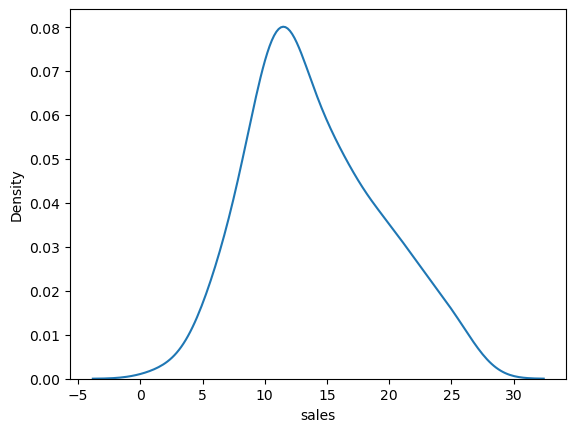

In [21]:
sns.kdeplot(df["sales"])

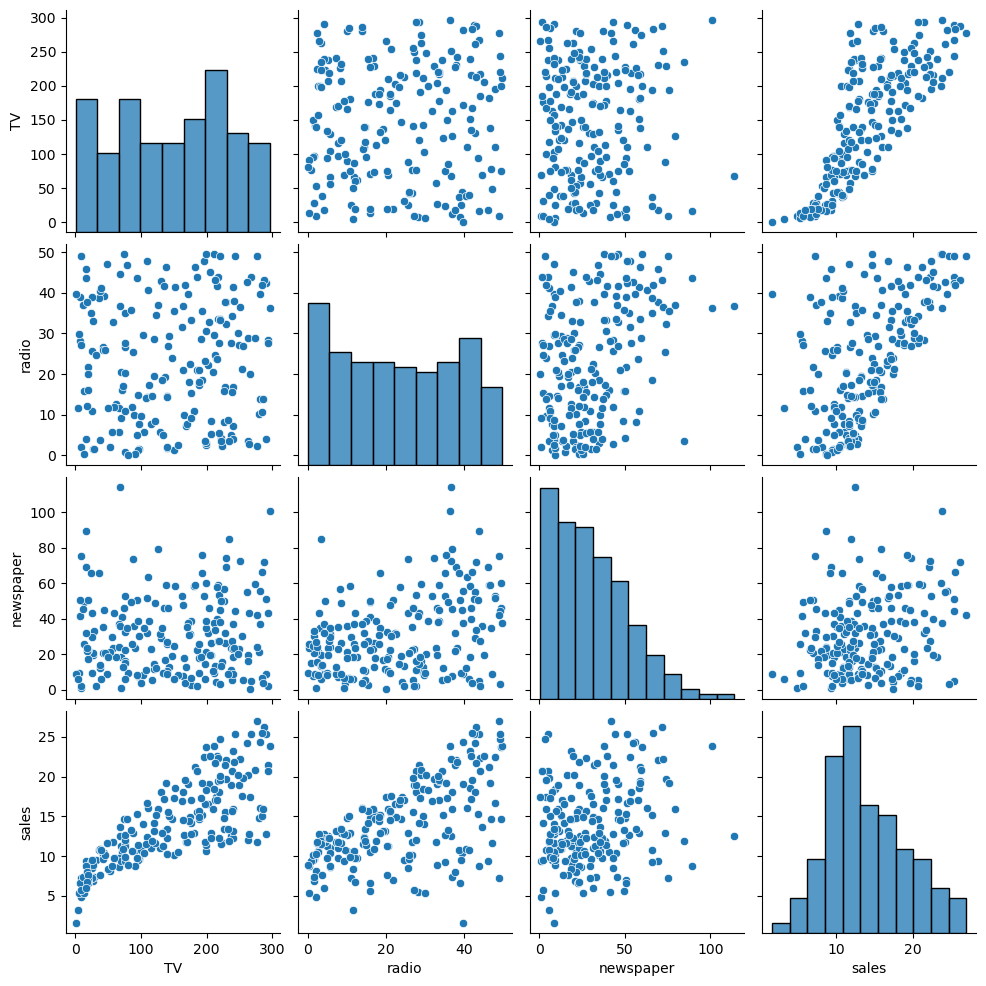

In [22]:
sns.pairplot(df)

<Axes: xlabel='TV', ylabel='sales'>

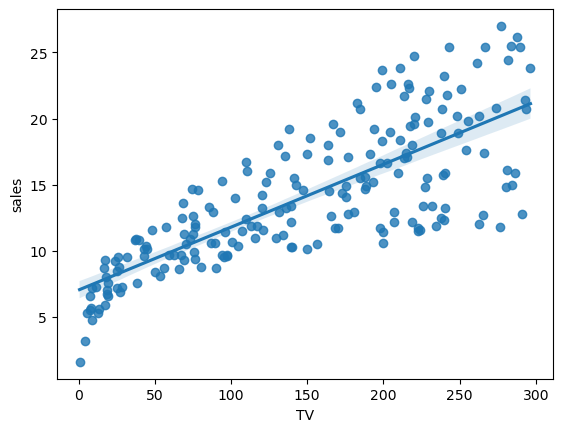

In [23]:
sns.regplot(x = df["TV"], y = df["sales"])

<Axes: xlabel='radio', ylabel='sales'>

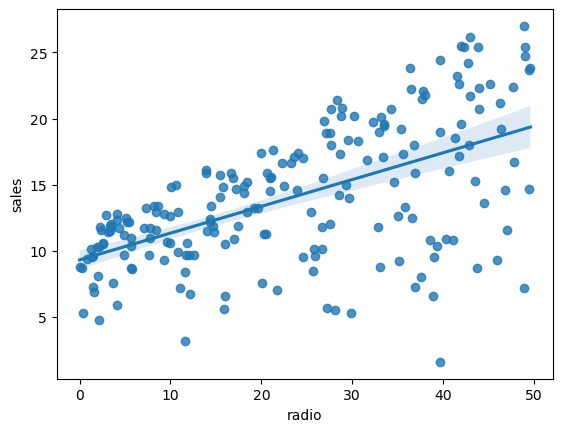

In [24]:
sns.regplot(x = df["radio"], y = df["sales"])

<Axes: xlabel='newspaper', ylabel='sales'>

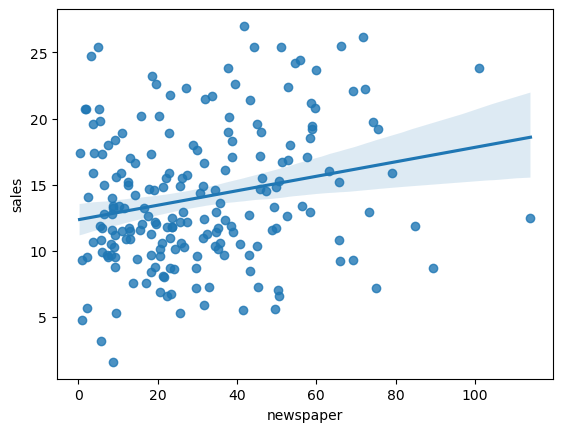

In [25]:
sns.regplot(x = df["newspaper"], y = df["sales"])

In [26]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [27]:
from sklearn.model_selection import train_test_split

In [35]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size= 0.8, random_state=42)

In [37]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [38]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
regression = LinearRegression()

In [41]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
X_train.head()

,TV,radio,newspaper
79,116.0,7.7,23.1
197,177.0,9.3,6.4
38,43.1,26.7,35.1
24,62.3,12.6,18.3
122,224.0,2.4,15.6


In [47]:
new_budget = [[490, 20, 20]]

In [48]:
regression.predict(new_budget)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28.73565427])

In [51]:
y_pred = regression.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [53]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("mse: ", mse)
print("mae: ", mae)
print("r2: ", r2)
print("rmse: ", rmse)

mse:  3.174097353976104
mae:  1.4607567168117606
r2:  0.899438024100912
rmse:  1.7815996615334502


In [55]:
regression.coef_

array([0.04472952, 0.18919505, 0.00276111])

In [56]:
regression.intercept_

np.float64(2.9790673381226256)

In [57]:
df["sales"].mean()

np.float64(14.0225)

In [58]:
## modelden newspaper çıkartılırsa

In [59]:
Xv1 = df[["TV", "radio"]]
yv1 = df["sales"]

In [60]:
Xv1_train, Xv1_test, yv1_train, yv1_test = train_test_split(Xv1, yv1, random_state=42, test_size=0.2)

In [61]:
regressionv1 = LinearRegression()

In [62]:
regressionv1.fit(Xv1_train, yv1_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
yv1_pred = regressionv1.predict(Xv1_test)

In [65]:
msev1 = mean_squared_error(yv1_test, yv1_pred)
maev1 = mean_absolute_error(yv1_test, yv1_pred)
r2v1 = r2_score(yv1_test, yv1_pred)
rmsev1 = root_mean_squared_error(yv1_test, yv1_pred)
print("mse: ", msev1)
print("mae: ", maev1)
print("r2: ", r2v1)
print("rmse: ", rmsev1)

mse:  3.137948009068354
mae:  1.444302313822758
r2:  0.9005833101920355
rmse:  1.7714254173033517


In [68]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print("mse: ", mse)
print("mae: ", mae)
print("r2: ", r2)
print("rmse: ", rmse)

mse:  3.174097353976104
mae:  1.4607567168117606
r2:  0.899438024100912
rmse:  1.7815996615334502


In [66]:
regressionv1.coef_

array([0.0447283 , 0.19066726])

In [67]:
regressionv1.intercept_

np.float64(3.028255250783303)